# Rate of Penetration (ROP) Prediction with Random Forest

**Goal:** predict ROP (ft/hr) from surface drilling parameters and formation properties,
and extract which levers actually matter.

**Technique highlights**
* Physics-inspired synthetic data (Bourgoyne–Young style response with interactions)
* **GroupShuffleSplit by well** — evaluate on unseen wells, not shuffled rows (no leakage)
* Random Forest vs. linear baseline, permutation importance, one-way sensitivity curves

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic drilling data

ROP follows a Bourgoyne–Young style multiplicative response: energy input (WOB, RPM)
raised to sub-linear exponents, divided by rock strength, damped by overbalance
(chip hold-down) and bit wear. Eight wells drill three formations of increasing strength.

In [2]:
N_WELLS, ROWS_PER_WELL = 8, 500
formations = pd.DataFrame({
    "formation": ["Shale_A", "Sand_B", "Carbonate_C"],
    "ucs_mean_psi": [8_000, 15_000, 26_000],
    "top_ft": [3_000, 7_500, 11_000],
})

frames = []
for w in range(N_WELLS):
    n = ROWS_PER_WELL
    depth = np.sort(rng.uniform(3_000, 14_000, n))
    fm_idx = np.searchsorted(formations["top_ft"].values, depth, side="right") - 1
    ucs = formations["ucs_mean_psi"].values[fm_idx] * rng.normal(1.0, 0.08, n)
    wob = rng.uniform(8, 45, n)                      # klbf
    rpm = rng.uniform(60, 200, n)
    flow = rng.uniform(350, 900, n)                  # gpm
    overbalance = rng.uniform(100, 900, n)           # psi
    bit_wear = np.clip(rng.beta(2, 5, n), 0, 0.8)    # 0 = sharp, 1 = worn out

    rop = (
        120.0
        * (wob / 30) ** 0.9
        * (rpm / 120) ** 0.6
        * (flow / 600) ** 0.25
        * (12_000 / ucs) ** 1.1
        * np.exp(-0.0006 * overbalance)
        * (1 - 0.75 * bit_wear)
        * np.exp(-0.00035 * (depth - 3_000) / 10)    # depth-related compaction trend
    )
    rop *= rng.lognormal(0, 0.12, n)                 # measurement / process noise

    frames.append(pd.DataFrame({
        "well": f"WELL-{w+1:02d}", "depth_ft": depth.round(0),
        "formation": formations["formation"].values[fm_idx],
        "ucs_psi": ucs.round(0), "wob_klbf": wob.round(1), "rpm": rpm.round(0),
        "flow_gpm": flow.round(0), "overbalance_psi": overbalance.round(0),
        "bit_wear_frac": bit_wear.round(3), "rop_ft_hr": rop.round(2),
    }))

df = pd.concat(frames, ignore_index=True)
df.to_csv("rop_drilling_data.csv", index=False)
print(df.shape)
df.head()

(4000, 10)


,well,depth_ft,formation,ucs_psi,wob_klbf,rpm,flow_gpm,overbalance_psi,bit_wear_frac,rop_ft_hr
0,WELL-01,3060.0,Shale_A,8917.0,20.7,185.0,578.0,286.0,0.229,103.23
1,WELL-01,3081.0,Shale_A,8059.0,14.6,98.0,637.0,769.0,0.416,34.47
2,WELL-01,3135.0,Shale_A,8372.0,33.1,76.0,504.0,217.0,0.025,118.74
3,WELL-01,3153.0,Shale_A,7964.0,39.3,194.0,368.0,281.0,0.441,199.85
4,WELL-01,3196.0,Shale_A,7891.0,9.5,82.0,688.0,539.0,0.307,36.24


## 2. Exploratory data analysis

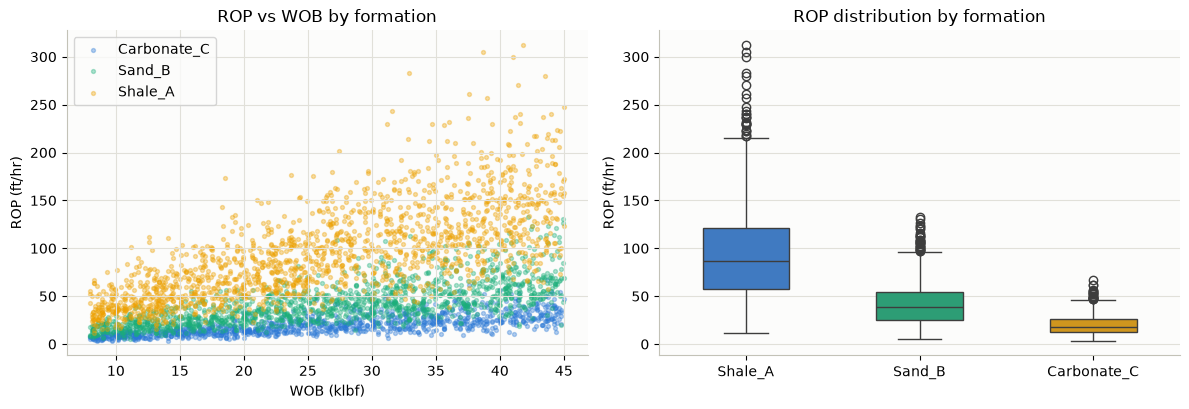

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for i, (fm, g) in enumerate(df.groupby("formation")):
    axes[0].scatter(g["wob_klbf"], g["rop_ft_hr"], s=8, alpha=0.35,
                    color=PALETTE[i], label=fm)
axes[0].set(xlabel="WOB (klbf)", ylabel="ROP (ft/hr)", title="ROP vs WOB by formation")
axes[0].legend()

sns.boxplot(data=df, x="formation", y="rop_ft_hr", ax=axes[1],
            hue="formation", palette=PALETTE[:3], legend=False, width=0.5)
axes[1].set(title="ROP distribution by formation", xlabel="", ylabel="ROP (ft/hr)")
plt.tight_layout()
plt.show()

Harder formations drill visibly slower, and the WOB response is noisy — exactly why a
multivariate model beats single-parameter drill-off rules.

## 3. Model training — grouped by well

Shuffled row splits leak intra-well correlation and flatter the metrics. We hold out
**entire wells** instead.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error

FEATURES = ["depth_ft", "ucs_psi", "wob_klbf", "rpm", "flow_gpm",
            "overbalance_psi", "bit_wear_frac"]
X, y, groups = df[FEATURES], df["rop_ft_hr"], df["well"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_tr, X_te, y_tr, y_te = X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]
print("Held-out wells:", sorted(df.iloc[test_idx]["well"].unique()))

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
lin = LinearRegression().fit(X_tr, y_tr)

for name, model in [("Random Forest", rf), ("Linear baseline", lin)]:
    pred = model.predict(X_te)
    print(f"{name:16s}  R2 = {r2_score(y_te, pred):.3f}   "
          f"MAE = {mean_absolute_error(y_te, pred):.2f} ft/hr")

Held-out wells: ['WELL-02', 'WELL-06']


Random Forest     R2 = 0.912   MAE = 8.57 ft/hr
Linear baseline   R2 = 0.769   MAE = 16.37 ft/hr


## 4. Evaluation & interpretation

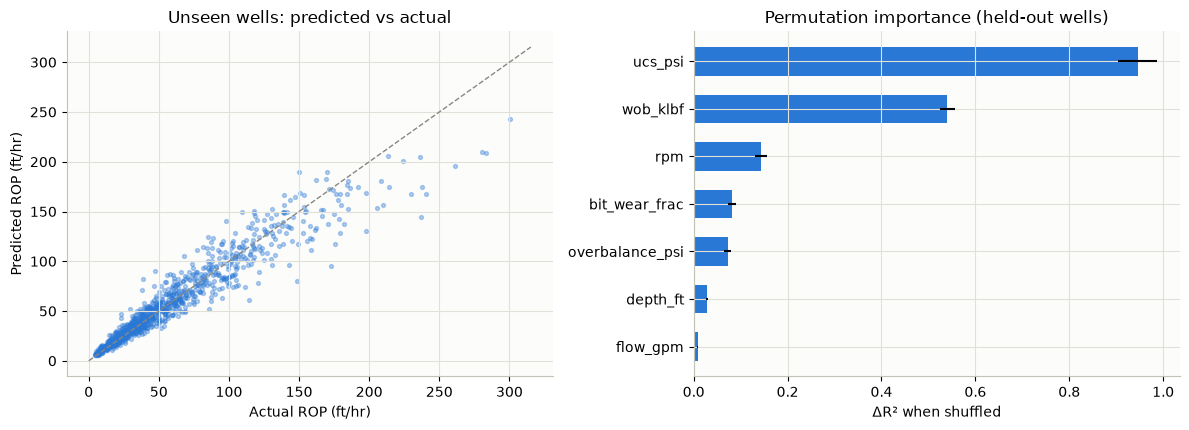

In [5]:
from sklearn.inspection import permutation_importance

pred = rf.predict(X_te)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(y_te, pred, s=8, alpha=0.35, color=PALETTE[0])
lims = [0, max(y_te.max(), pred.max()) * 1.05]
axes[0].plot(lims, lims, color="#898781", lw=1, ls="--")
axes[0].set(xlabel="Actual ROP (ft/hr)", ylabel="Predicted ROP (ft/hr)",
            title="Unseen wells: predicted vs actual")

imp = permutation_importance(rf, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)
order = np.argsort(imp.importances_mean)
axes[1].barh([FEATURES[i] for i in order], imp.importances_mean[order],
             xerr=imp.importances_std[order], color=PALETTE[0], height=0.6)
axes[1].set(title="Permutation importance (held-out wells)", xlabel="ΔR² when shuffled")
plt.tight_layout()
plt.show()

## 5. Parameter sensitivity — what should the driller change?

Sweep WOB and RPM one at a time around a reference operating point in the carbonate.

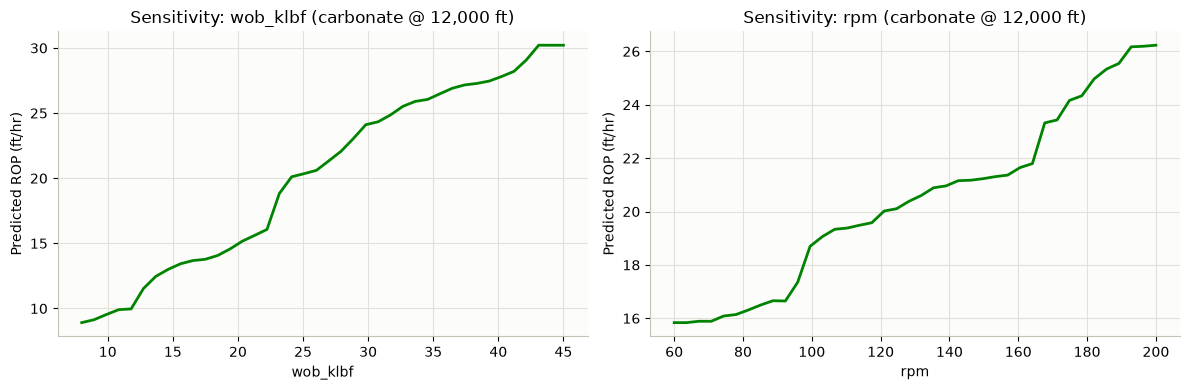

In [6]:
ref = X_tr.median().to_dict()
ref.update({"ucs_psi": 26_000, "depth_ft": 12_000})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, param, rng_vals in [
    (axes[0], "wob_klbf", np.linspace(8, 45, 40)),
    (axes[1], "rpm", np.linspace(60, 200, 40)),
]:
    sweep = pd.DataFrame([{**ref, param: v} for v in rng_vals])[FEATURES]
    ax.plot(rng_vals, rf.predict(sweep), lw=2, color=PALETTE[3])
    ax.set(xlabel=param, ylabel="Predicted ROP (ft/hr)",
           title=f"Sensitivity: {param} (carbonate @ 12,000 ft)")
plt.tight_layout()
plt.show()

## Conclusions

* The Random Forest recovers the non-linear physics (R² ≈ 0.9 on **unseen wells**) and
  roughly halves the MAE of the linear baseline.
* Permutation importance correctly ranks rock strength, WOB and bit wear as the dominant
  drivers — matching drilling physics, which builds trust with drilling engineers.
* The sensitivity sweeps turn the model into an advisory tool: "at this depth and
  formation, +5 klbf WOB is worth ~X ft/hr".
* **Next step:** feed real-time WITSML data and retrain per-field; add MSE (mechanical
  specific energy) as a derived feature.